<a href="https://colab.research.google.com/github/LeonardoVS-dev/Fundamentos/blob/main/pivot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pivot e pivot_table

In [49]:
import pandas as pd
import numpy as np

dados_eleitorais = pd.read_csv("/content/votacao_candidato_munzona_2024_RR LIMPADO_CORRIGIDO.csv", encoding="latin-1", sep=";")
dados_flight = pd.read_csv("https://raw.githubusercontent.com/LeonardoVS-dev/Fundamentos/refs/heads/main/dataset/flights.csv", sep=",")

In [48]:
# Comparação entre pivot e pivot_table, com base nos DFs anteriores
dataframe_pivot = df1.pivot(index='Valor', columns='ColunaB', values='ColunaC')
display(dataframe_pivot)

# Aqui, a principal diferença é que o pivot_table permite usar a função aggfunc
dataframe_pivot_table = df1.pivot_table(index='Valor', columns='ColunaB', values='ColunaC', aggfunc="count")
display(dataframe_pivot_table)

ColunaB,T,U,V,W,X,Y,Z
Valor,,,,,,,
188,Gamma,NaN,NaN,NaN,NaN,NaN,NaN
452,NaN,NaN,NaN,NaN,NaN,NaN,Alpha
584,NaN,NaN,NaN,Beta,NaN,NaN,NaN
662,NaN,NaN,Epsilon,NaN,NaN,NaN,NaN
690,NaN,Delta,NaN,NaN,NaN,NaN,NaN
723,NaN,NaN,NaN,NaN,Zeta,NaN,NaN
860,NaN,NaN,NaN,NaN,NaN,Eta,NaN


ColunaB,T,U,V,W,X,Y,Z
Valor,,,,,,,
188,1.0,NaN,NaN,NaN,NaN,NaN,NaN
452,NaN,NaN,NaN,NaN,NaN,NaN,1.0
584,NaN,NaN,NaN,1.0,NaN,NaN,NaN
662,NaN,NaN,1.0,NaN,NaN,NaN,NaN
690,NaN,1.0,NaN,NaN,NaN,NaN,NaN
723,NaN,NaN,NaN,NaN,1.0,NaN,NaN
860,NaN,NaN,NaN,NaN,NaN,1.0,NaN


In [25]:
# Remoção de colunas indesejadas / desnecessárias com o drop()
# 13 é o código de vereador, 11 é o de prefeito

tabela_eleicao = dados_eleitorais.groupby(["NM_MUNICIPIO", "NR_ZONA", "NM_CANDIDATO", "NM_URNA_CANDIDATO", "NR_PARTIDO", "SG_PARTIDO"]).sum().reset_index()
tabela_eleicao.drop(["NM_MUNICIPIO", "NR_ZONA", "NM_CANDIDATO", "NM_URNA_CANDIDATO", "NR_PARTIDO", "SG_PARTIDO"], axis=1, inplace=True)
tabela_eleicao.head(10)

,CD_CARGO,NM_PARTIDO,QT_VOTOS_NOMINAIS
0,13,Partido Democrático Trabalhista,267
1,13,Partido Social Democrático,660
2,13,REPUBLICANOS,352
3,13,Partido Social Democrático,112
4,13,REPUBLICANOS,557
5,13,PROGRESSISTAS,7
6,13,Podemos,130
7,13,Partido Social Democrático,470
8,13,Podemos,159
9,13,REPUBLICANOS,164


In [27]:
# Aplicação do pivot_table, com base na tabela anterior

# Aqui, ele mostra a soma (através do aggfunc) de votos de todos os candidatos a vereador e
# prefeito por nome do partido, com o pivot_table atuando para mostrar os
# códigos de cargo como colunas
a = tabela_eleicao.pivot_table(index="NM_PARTIDO", columns="CD_CARGO", values="QT_VOTOS_NOMINAIS", aggfunc="sum")

# Essa linha, através do Numpy, serve para trocar todos os NaN (dos candidatos que não receberam
# votos) por None.
replaced_df = a.replace({np.nan: None})
replaced_df

CD_CARGO,11,13
NM_PARTIDO,,
AVANTE,None,2092.0
Cidadania,3117.0,2263.0
Democracia Cristã,None,15395.0
Movimento Democrático Brasileiro,134526.0,31956.0
PROGRESSISTAS,39521.0,44068.0
Partido Comunista do Brasil,None,279.0
Partido Democrático Trabalhista,7267.0,34259.0
Partido Liberal,5167.0,8863.0
Partido Novo,449.0,5192.0


<Axes: xlabel='NM_PARTIDO'>

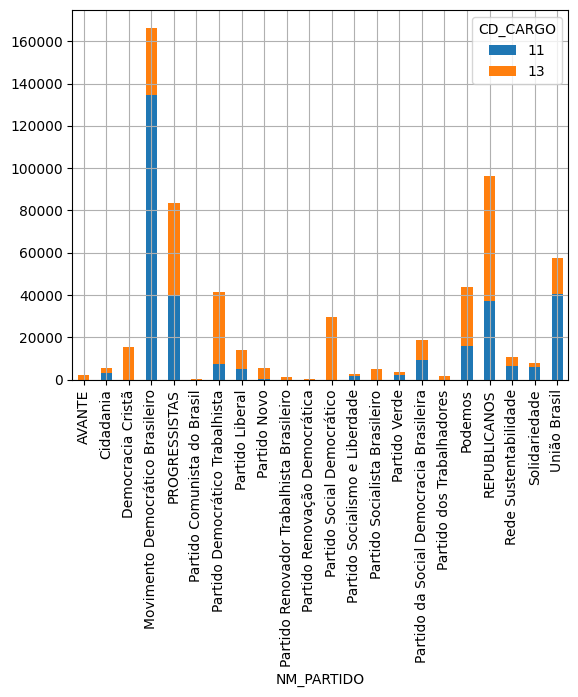

In [29]:
# Plot gráfico com base no DF anterior

# A partir do gráfico, podemos observar a clara dominância do MDB nas eleições
# de 2024 em Roraima
replaced_df.plot(kind="bar", stacked=True, grid=True)

## Com dados do arquivo Flight, seguindo o roteiro do issue

In [96]:
# Criação do dataframe com base no dado flight
df_flight = pd.DataFrame(dados_flight)

### Issue - Parte 1

In [111]:
# 1.1
display(df_flight.pivot(index="month", columns="year", values="passengers"))

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Apr,129,135,163,181,235,227,269,313,348,348,396,461
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Dec,118,140,166,194,201,229,278,306,336,337,405,432
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Mar,132,141,178,193,236,235,267,317,356,362,406,419
May,121,125,172,183,229,234,270,318,355,363,420,472


<Axes: xlabel='year'>

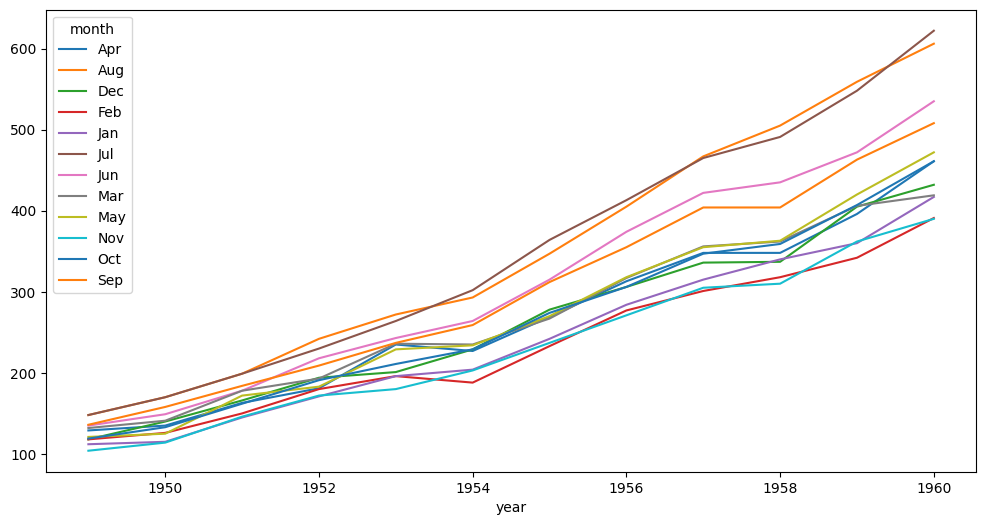

In [107]:
# B.1
df_flight_plot = df_flight.pivot(index="year", columns="month", values="passengers").plot(figsize=(12,6))
display(df_flight_plot)

In [58]:
# 1.2
display(df_flight.pivot(index="year", columns="month", values="passengers"))

month,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
year,,,,,,,,,,,,
1949,129,148,118,118,112,148,135,132,121,104,119,136
1950,135,170,140,126,115,170,149,141,125,114,133,158
1951,163,199,166,150,145,199,178,178,172,146,162,184
1952,181,242,194,180,171,230,218,193,183,172,191,209
1953,235,272,201,196,196,264,243,236,229,180,211,237
1954,227,293,229,188,204,302,264,235,234,203,229,259
1955,269,347,278,233,242,364,315,267,270,237,274,312
1956,313,405,306,277,284,413,374,317,318,271,306,355
1957,348,467,336,301,315,465,422,356,355,305,347,404


### Issue - Parte 2

In [70]:
# 2.1
# Aqui, remove a coluna "month", especificando o eixo do qual deve ser removido
df_flight_month = df_flight.drop(["month"], axis=1)
# Mostra o dataframe que soma o total de passageiros por ano
display(df_flight_month.pivot_table(index="year", aggfunc="sum"))

,passengers
year,
1949,1520
1950,1676
1951,2042
1952,2364
1953,2700
1954,2867
1955,3408
1956,3939
1957,4421


In [71]:
# 2.2
# O dataframe soma o total, calcula a média e o maior valor de passageiros por ano, respectivamente
display(df_flight_month.pivot_table(index="year", aggfunc=["sum", "mean", "max"]))

,sum,mean,max
,passengers,passengers,passengers
year,,,
1949,1520,126.666667,148
1950,1676,139.666667,170
1951,2042,170.166667,199
1952,2364,197.000000,242
1953,2700,225.000000,272
1954,2867,238.916667,302
1955,3408,284.000000,364
1956,3939,328.250000,413


In [102]:
# 2.3
df_flight_season = df_flight.copy()

# Define os meses de cada estação
winter_months = ["Dec", "Jan", "Feb"]
summer_months = ["Jun", "Jul", "Aug"]
spring_months = ["Mar", "Apr", "May"]
autumn_months = ["Sep", "Oct", "Nov"]

# Aplica a mudança de mês para a de estação na coluna season
df_flight_season.loc[df_flight_season["month"].isin(winter_months), "season"] = "Winter"
df_flight_season.loc[df_flight_season["month"].isin(summer_months), "season"] = "Summer"
df_flight_season.loc[df_flight_season["month"].isin(spring_months), "season"] = "Spring"
df_flight_season.loc[df_flight_season["month"].isin(autumn_months), "season"] = "Autumn"

display(df_flight_season.pivot_table(index="year", columns="season", values="passengers", aggfunc="mean"))


season,Autumn,Spring,Summer,Winter,All
year,,,,,
1949,119.666667,127.333333,143.666667,116.000000,126.666667
1950,135.000000,133.666667,163.000000,127.000000,139.666667
1951,164.000000,171.000000,192.000000,153.666667,170.166667
1952,190.666667,185.666667,230.000000,181.666667,197.000000
1953,209.333333,233.333333,259.666667,197.666667,225.000000
1954,230.333333,232.000000,286.333333,207.000000,238.916667
1955,274.333333,268.666667,342.000000,251.000000,284.000000
1956,310.666667,316.000000,397.333333,289.000000,328.250000
1957,352.000000,353.000000,451.333333,317.333333,368.416667


### Issue - Parte 3

In [ ]:
# 3.1
display(df_flight_season.pivot(index="year", columns="season").mean())

Retorno de erro: ValueError: Index contains duplicate entries, cannot reshape. O erro indice que o índice contém valores duplicados e que não é possível "remodelar" o Dataframe

In [105]:
# 3.2
# Sem margins=True
display(df_flight_month.pivot_table(index="year", aggfunc="sum"))

# Com margins=True
display(df_flight_month.pivot_table(index="year", aggfunc="sum", margins=True))

,passengers
year,
1949,1520
1950,1676
1951,2042
1952,2364
1953,2700
1954,2867
1955,3408
1956,3939
1957,4421


,passengers
year,
1949,1520
1950,1676
1951,2042
1952,2364
1953,2700
1954,2867
1955,3408
1956,3939
1957,4421


Usar o ``` margins = True ``` faz com que apareça um campo somando o total no pé da tabela.



### Issue - Parte 4

In [106]:
# 4.1
display(df_flight.pivot(index="month", columns="year", values="passengers").melt())

,year,value
0,1949,129
1,1949,148
2,1949,118
3,1949,118
4,1949,112
...,...,...
139,1960,419
140,1960,472
141,1960,390
142,1960,461


### Parte Bônus

In [113]:
# B.2
# Copia o dataframe df_flight
df_flight_decade = df_flight.copy()

# Cria a coluna decade, que recebe o ano, o divide por 10 e arredonda para baixo,
# multiplicando o resultado por 10
df_flight_decade["decade"] = ((df_flight_decade["year"] // 10) * 10)

display(df_flight_decade.pivot_table(index="decade", columns="month", values="passengers", aggfunc="mean"))

month,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
decade,,,,,,,,,,,,
1940,129.0,148.0,118.0,118.0,112.0,148.0,135.0,132.0,121.0,104.0,119.0,136.0
1950,261.5,345.9,259.2,231.1,237.2,344.6,307.0,269.1,266.9,230.0,261.9,298.5
1960,461.0,606.0,432.0,391.0,417.0,622.0,535.0,419.0,472.0,390.0,461.0,508.0
